<a href="https://colab.research.google.com/github/jben-hun/pyground/blob/main/notebooks/imageTiler.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Definitions

In [1]:
import requests
import skimage
import skimage.io
import numpy as np
from PIL import Image
from io import BytesIO
from google import colab

In [2]:
MAX_SHAPE = (512, 512)


def tile(*, image, dim, pos):
  h, w = image.shape[:2]

  new_shape = list(image.shape)
  new_shape[0] = h*dim[0]
  new_shape[1] = w*dim[1]

  tiled = np.zeros_like(image, shape=new_shape)

  # prepare flips
  image_yx = np.flip(image, (0, 1))
  image_y = np.flipud(image)
  image_x = np.fliplr(image)

  for y in range(dim[0]):
    for x in range(dim[1]):
      rel_y = y - pos[0]
      rel_x = x - pos[1]

      flip_x, flip_y = False, False

      if rel_y % 2 != 0:
        flip_y = True
      if rel_x % 2 != 0:
        flip_x = True

      # no flip
      if True not in (flip_y, flip_x):
        tiled[h*y:h*(y+1), w*x:w*(x+1)] = image
      # flip y & x
      elif flip_y and flip_x:
        tiled[h*y:h*(y+1), w*x:w*(x+1)] = image_yx
      # flip y
      elif flip_y:
        tiled[h*y:h*(y+1), w*x:w*(x+1)] = image_y
      # flip x
      else:
        tiled[h*y:h*(y+1), w*x:w*(x+1)] = image_x

  return tiled


# Same result using np.pad
def tile_np(*, image, dim, pos):
  h, w = image.shape[:2]
  y, x = pos

  return np.pad(a, (
      (h*y, h*(dim[0]-1-y)),
      (w*x, w*(dim[1]-1-x)),
      (0, 0)
      ), "symmetric")

# Demo

**Choose an option to provide a source image**

In [ ]:
# either upload a local image...
uploaded = colab.files.upload()
assert uploaded, "Please supply a file"
raw = next(iter(uploaded.values()))

In [3]:
# ...or use an URL
url = "http://wedding.beleon.com/media/8866-beleontoursgreeceweddingzakynthosislandkameo03.JPG"  #@param {type: "string"}
raw = requests.get(url).content

Process the image

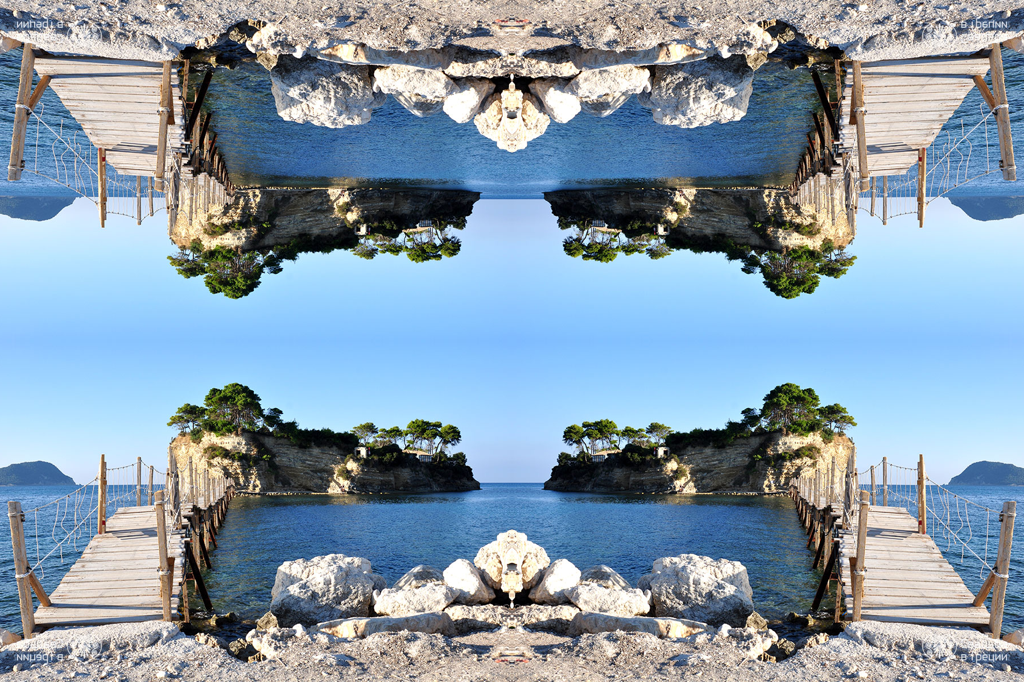

In [4]:
im = Image.open(BytesIO(raw))
im.thumbnail(MAX_SHAPE)
a = np.array(im)
im = tile(image=a, dim=(2, 2), pos=(1, 1))
Image.fromarray(im)

# Speed comparison

In [5]:
a = np.empty((1000, 1000, 3))

def test(f):
  f(image=a, dim=(11, 11), pos=(5, 5))

**loop method**

In [6]:
%%timeit

test(tile)

1 loop, best of 3: 1.07 s per loop


versus

**np.pad method**

In [7]:
%%timeit

test(tile_np)

1 loop, best of 3: 1.5 s per loop
